# Gradient Descent and Loss Functions

**Unit:** Unit 3: AI Concepts, Terminology, and Application Domains Part 2

In notebook `01_regression_classification.ipynb` we called `LinearRegression()` and `LogisticRegression()` and sklearn fitted them for us -- but *how* does a model actually find good parameters? Every trainable model in this diploma (from linear regression to deep neural networks) learns the same way: define a **loss function** that measures how wrong the model is, then use **gradient descent** to repeatedly nudge the parameters in the direction that reduces that loss. In this lab we open the black box and implement both pieces by hand in NumPy, so that when Keras prints `loss:` during training later in the course, you know exactly what is happening.

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement Mean Squared Error (MSE) and its gradient in pure NumPy
- Write a gradient descent loop and watch the loss shrink step by step
- See experimentally what happens when the learning rate is too small, good, or too large
- Implement binary cross-entropy loss and train a logistic regression with it
- Know when to use MSE vs cross-entropy

## 🔗 Where this fits

**Builds on:** Unit 3, lesson 01 "Regression vs Classification" — sklearn fitted those models for you; here you open the box.

**Used later in:** Every trainable model in the rest of the diploma — Course 03 (AIAT 113) Unit 2 derives these gradients with calculus, and Course 08 (AIAT 122) Unit 1 scales the same loop to deep networks.

---


## 🎯 The knob that stops a two-month training run

When Meta released **OPT-175B** in May 2022 it did something unusual: it published
the training **logbook** alongside the model, so anyone could read what actually
happened over two months on a large GPU cluster. Among the recorded problems were
**loss divergences** — the loss climbing instead of falling — and the fix the team
applied each time was the one you are about to see in section 2 of this notebook:
**lower the learning rate and restart from an earlier checkpoint.**

That is worth sitting with. A frontier-scale training run, a team of specialists,
months of compute — and one of the recurring failure modes is the same
single-number knob that is about to blow up a two-parameter line fit on 442
diabetes patients. The learning rate does not become less important as models get
bigger. It becomes more expensive to get wrong.

### What goes wrong without understanding the loss and its gradient

You call `LinearRegression().fit()`, you get a model, and you cannot answer the
only questions that matter when it misbehaves: *why did training stop here*, *is
this the best possible fit or a stuck one*, and *is the remaining error the
world's fault or mine?* Section 1 below answers all three by hand — the loop lands
on exactly the closed-form least-squares solution, so the residual error is
provably the data's, not the algorithm's. That distinction is the difference
between tuning for a week and knowing when to stop.


## 1. Fitting a Line by Hand: MSE + Gradient Descent

**The setup.** We use a **real** 1-feature dataset: 442 diabetes patients from Efron et al. (2004), shipped inside scikit-learn. The feature is each patient's **body mass index**; the target is a quantitative measure of **disease progression one year later**. Our model is `y_pred = w*x + b` and we start from the worst possible guess: `w = 0, b = 0`.

**Why real data changes the story.** With invented data you can print the "true" line you generated and check the model recovered it. Real patients have no true line — BMI explains *part* of disease progression and nothing more. So the loss will fall steeply and then **stop at a value well above zero**, and that floor is genuine unexplained variation (genetics, diet, medication, measurement error), not a mistake in the algorithm.

**The loss.** Mean Squared Error averages the squared distance between predictions and truth:

$$\mathrm{MSE}(w, b) = \frac{1}{n}\sum_{i=1}^{n} (w x_i + b - y_i)^2$$

**The gradient.** Calculus gives us the direction of steepest *increase* of the loss, so we step the opposite way:

$$\frac{\partial \mathrm{MSE}}{\partial w} = \frac{2}{n}\sum_i (w x_i + b - y_i)\,x_i \qquad \frac{\partial \mathrm{MSE}}{\partial b} = \frac{2}{n}\sum_i (w x_i + b - y_i)$$

Each iteration: `w = w - lr * dw` and `b = b - lr * db`. That is the entire algorithm.

In [1]:
# Gradient descent from scratch on a REAL line-fitting problem: define the MSE loss,
# derive its gradients, and repeatedly step downhill — no ML library involved.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

# Real data: 442 diabetes patients (Efron et al., 2004), bundled with scikit-learn.
# scaled=False gives the measurements in their original units so we can read them.
diabetes = load_diabetes(scaled=False)
bmi = diabetes.data[:, list(diabetes.feature_names).index("bmi")]
y = diabetes.target.astype(float)

# Standardize the feature to mean 0 / std 1. WHY: the size of a gradient step depends on
# the scale of x, so standardizing lets a single learning rate work for any feature.
x = (bmi - bmi.mean()) / bmi.std()
n = len(x)

print(f"Dataset: {n} real patients, 1 feature (body mass index, standardized)")
print(f"  BMI                 : min {bmi.min():.1f}, mean {bmi.mean():.1f}, max {bmi.max():.1f}")
print(f"  Disease progression : min {y.min():.0f}, mean {y.mean():.1f}, max {y.max():.0f}")
print("  No 'true line' exists here — BMI explains only part of disease progression.")


def mse_loss(w, b, x, y):
    """Mean Squared Error of the line y_pred = w*x + b."""
    error = (w * x + b) - y
    return np.mean(error ** 2)


def mse_gradients(w, b, x, y):
    """Partial derivatives of MSE with respect to w and b."""
    error = (w * x + b) - y
    dw = 2 * np.mean(error * x)
    db = 2 * np.mean(error)
    return dw, db


# Gradient descent loop
# The learning loop: start from w=b=0 and take 200 small steps against the gradient.
w, b = 0.0, 0.0
lr = 0.1
steps = 200
loss_history = []

print(f"\nGradient descent: lr = {lr}, {steps} steps, start w = 0, b = 0")
print(f"{'step':>5} {'loss (MSE)':>12} {'w':>8} {'b':>8}")
for step in range(steps + 1):
    loss = mse_loss(w, b, x, y)
    loss_history.append(loss)
    if step % 20 == 0:
        print(f"{step:>5} {loss:>12.4f} {w:>8.3f} {b:>8.3f}")
    dw, db = mse_gradients(w, b, x, y)
    w -= lr * dw
    b -= lr * db

print(f"\nLearned line:  progression = {w:.2f} * (standardized BMI) + {b:.2f}")
print(f"Final MSE: {loss_history[-1]:.2f}   (start: {loss_history[0]:.2f})")

# Sanity check: the closed-form least-squares solution to the same problem.
# WHY: it proves the loop is not approximating something vague — it converged to the
# provably best straight line, the one sklearn's LinearRegression would return.
design = np.vstack([x, np.ones_like(x)]).T
w_ols, b_ols = np.linalg.lstsq(design, y, rcond=None)[0]
print(f"Closed-form least squares: w = {w_ols:.2f}, b = {b_ols:.2f}")
r2 = 1 - loss_history[-1] / np.var(y)
print(f"R^2 of that best line: {r2:.3f} — BMI alone explains {r2:.1%} of the variation,")
print("so the remaining MSE is real unexplained variation, not a training failure.")

Dataset: 442 real patients, 1 feature (body mass index, standardized)
  BMI                 : min 18.0, mean 26.4, max 42.2
  Disease progression : min 25, mean 152.1, max 346
  No 'true line' exists here — BMI explains only part of disease progression.

Gradient descent: lr = 0.1, 200 steps, start w = 0, b = 0
 step   loss (MSE)        w        b
    0   29074.4819    0.000    0.000
   20    3893.8041   44.639  150.380
   40    3890.4570   45.154  152.113
   60    3890.4566   45.160  152.133
   80    3890.4566   45.160  152.133
  100    3890.4566   45.160  152.133
  120    3890.4566   45.160  152.133
  140    3890.4566   45.160  152.133
  160    3890.4566   45.160  152.133
  180    3890.4566   45.160  152.133
  200    3890.4566   45.160  152.133

Learned line:  progression = 45.16 * (standardized BMI) + 152.13
Final MSE: 3890.46   (start: 29074.48)
Closed-form least squares: w = 45.16, b = 152.13
R^2 of that best line: 0.344 — BMI alone explains 34.4% of the variation,
so the remainin

The printed table shows the loss collapsing from **29,074.48 at step 0** (the flat line `y = 0` misses every patient) to **3,890.46**, which it reaches by about step 40 and then holds for the remaining 160 steps. The learned parameters — `w = 45.16`, `b = 152.13` — are **identical to the closed-form least-squares solution** printed underneath, so the loop really did find the best possible straight line.

That plateau at 3,890.46 is *not* a failure. It corresponds to an R² of **0.344**: body mass index alone accounts for about a third of the variation in disease progression, and the other two thirds belong to everything we did not measure. On real data the bottom of the loss curve is always above zero, and reading that floor honestly is a skill in itself.

### Visualize: loss curve and fitted line

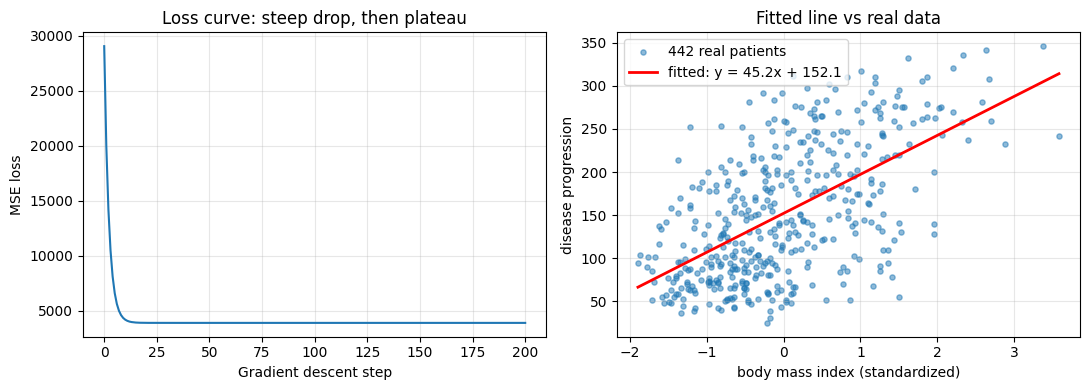

Left: most of the loss disappears in the first few dozen steps, then flattens.
Right: the red line is the best straight line through a genuinely scattered cloud —
the vertical spread that remains is what BMI alone cannot explain.


In [2]:
# Visual check of what training just did: the loss curve (left) and the fitted line
# on top of the data (right) — the two plots you should draw after ANY training run.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Loss curve
ax1.plot(loss_history, color='tab:blue')
ax1.set_xlabel('Gradient descent step')
ax1.set_ylabel('MSE loss')
ax1.set_title('Loss curve: steep drop, then plateau')
ax1.grid(alpha=0.3)

# Data + fitted line
xs = np.linspace(x.min(), x.max(), 100)
ax2.scatter(x, y, s=14, alpha=0.5, label='442 real patients')
ax2.plot(xs, w * xs + b, 'r-', lw=2, label=f'fitted: y = {w:.1f}x + {b:.1f}')
ax2.set_xlabel('body mass index (standardized)')
ax2.set_ylabel('disease progression')
ax2.set_title('Fitted line vs real data')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("Left: most of the loss disappears in the first few dozen steps, then flattens.")
print("Right: the red line is the best straight line through a genuinely scattered cloud —")
print("the vertical spread that remains is what BMI alone cannot explain.")

## 2. Comparative Experiment: the Learning Rate

The gradient tells us the *direction* to move; the learning rate `lr` decides the *step size*. We now change **exactly one thing** -- the learning rate -- and re-run the identical gradient descent loop three times on the same data, same start point, same 200 steps:

| run | lr | expectation |
|-----|------|-------------|
| too small | 0.001 | crawls -- barely reduces the loss |
| good | 0.1 | converges to the least-squares optimum |
| too large | 1.2 | overshoots -- loss explodes |

=== Learning rate comparison (same data, same start, 200 steps) ===
      run  learning rate  steps taken           final loss    status
too small          0.001          200          15,197.3074 converged
     good          0.100          200           3,890.4566 converged
too large          1.200           26 999,500,473,489.8492  DIVERGED


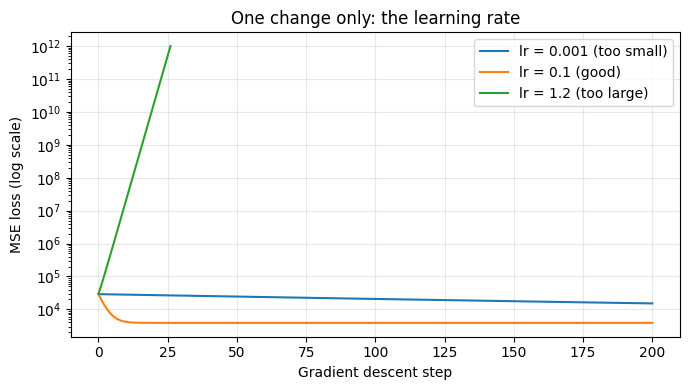

In [3]:
# The learning rate is the one knob that makes or breaks gradient descent: too small
# crawls, too large explodes. Same data, same start — only lr changes.
def run_gradient_descent(lr, steps=200):
    """Run GD from w=b=0; stop early if the loss blows up. Returns loss history + status."""
    w, b = 0.0, 0.0
    history = []
    for step in range(steps + 1):
        loss = mse_loss(w, b, x, y)
        if not np.isfinite(loss) or loss > 1e12:
            return history, 'DIVERGED'
        history.append(loss)
        dw, db = mse_gradients(w, b, x, y)
        w -= lr * dw
        b -= lr * db
    return history, 'converged'


# Three runs that differ ONLY in learning rate — compare their loss histories.
experiments = {'too small': 0.001, 'good': 0.1, 'too large': 1.2}
results = []
histories = {}
for name, lr_i in experiments.items():
    hist, status = run_gradient_descent(lr_i)
    histories[name] = hist
    results.append({'run': name, 'learning rate': lr_i,
                    'steps taken': len(hist) - 1,
                    'final loss': hist[-1], 'status': status})

summary = pd.DataFrame(results)
print("=== Learning rate comparison (same data, same start, 200 steps) ===")
print(summary.to_string(index=False,
                        formatters={'final loss': lambda v: f'{v:,.4f}'}))

# Loss curves on a log scale so all three runs fit on one plot
plt.figure(figsize=(7, 4))
for name, hist in histories.items():
    plt.plot(hist, label=f"lr = {experiments[name]} ({name})")
plt.yscale('log')
plt.xlabel('Gradient descent step')
plt.ylabel('MSE loss (log scale)')
plt.title('One change only: the learning rate')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Conclusion from the table above:**

- **lr = 0.001 (too small)** never diverges, but after all 200 steps the loss is still **15,197.31** -- barely half-way down from 29,074 and nowhere near the 3,890.46 optimum. It moved in the right direction the whole time, just in tiny steps. It would eventually get there, but "eventually" can mean thousands of steps.
- **lr = 0.1 (good)** reaches **3,890.46**, the least-squares optimum -- the same result as Section 1.
- **lr = 1.2 (too large) is the run that diverged**: its loss passed 10^12 after only **26 steps** and the loop stopped early. **Why:** each update is `lr * gradient`. When the step is more than twice the distance to the minimum, the parameters land *farther* from the optimum than where they started, which makes the next gradient even bigger -- so every step overshoots by more than the last and the loss grows exponentially (a straight climbing line on the log-scale plot).

This is why "my loss is NaN/exploding" in deep learning almost always means *lower the learning rate first*.

## 3. Cross-Entropy: the Loss for Classification

MSE measures distance between *numbers*, which is right for regression. For classification the model outputs a **probability** and the labels are 0/1 -- so we instead use **binary cross-entropy (BCE)**, which heavily punishes confident wrong answers:

$$\mathrm{BCE} = -\frac{1}{n}\sum_{i=1}^{n}\Big[y_i \log(p_i) + (1 - y_i)\log(1 - p_i)\Big], \qquad p_i = \sigma(\mathbf{w}^\top \mathbf{x}_i + b)$$

Predicting `p = 0.01` for a true 1 costs `-log(0.01) ≈ 4.6`; predicting `p = 0.99` costs only `-log(0.99) ≈ 0.01`. We train the exact same way -- compute gradient, step downhill -- only the loss function changed. This is literally what sklearn's `LogisticRegression` (used in notebook 01) minimizes internally.

Dataset: 569 real biopsies, features ['mean radius', 'mean texture']
Classes: [212 357] (0 = malignant / 1 = benign)

Gradient descent on cross-entropy: lr = 0.5, 300 steps
 step   loss (BCE)  accuracy
    0       0.6931    62.74%
   50       0.2760    88.75%
  100       0.2620    88.93%
  150       0.2582    88.75%
  200       0.2569    89.10%
  250       0.2563    89.28%
  300       0.2560    89.10%

BCE went from 0.6931 (random guessing: -log(0.5) = 0.693) to 0.2560
Final training accuracy: 89.10%


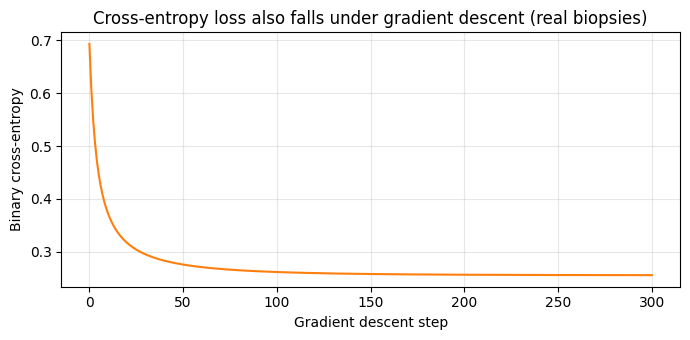

In [4]:
# Same algorithm, different loss: swap MSE for binary cross-entropy and the identical
# update loop now trains a CLASSIFIER — losses are plug-ins, gradient descent is universal.
from sklearn.datasets import load_breast_cancer

# Real 2-class dataset: 569 breast-tumour biopsies (Wisconsin Diagnostic, UCI).
# We keep two of the 30 measured features so the problem stays hand-computable.
cancer = load_breast_cancer()
feature_pair = ["mean radius", "mean texture"]
cols = [list(cancer.feature_names).index(f) for f in feature_pair]
X = cancer.data[:, cols]
y_cls = cancer.target                       # 1 = benign, 0 = malignant
X = (X - X.mean(axis=0)) / X.std(axis=0)    # standardize for stable gradient descent
print(f"Dataset: {X.shape[0]} real biopsies, features {feature_pair}")
print(f"Classes: {np.bincount(y_cls)} (0 = malignant / 1 = benign)")


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def bce_loss(w_vec, b, X, y):
    """Binary cross-entropy of logistic model p = sigmoid(Xw + b)."""
    p = sigmoid(X @ w_vec + b)
    p = np.clip(p, 1e-12, 1 - 1e-12)   # avoid log(0)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))


def bce_gradients(w_vec, b, X, y):
    """Gradient of BCE -- same shape of update rule as MSE, different loss."""
    p = sigmoid(X @ w_vec + b)
    dw = X.T @ (p - y) / len(y)
    db = np.mean(p - y)
    return dw, db


# The very same loop as Section 1 -- only the loss/gradient functions changed
w_vec = np.zeros(X.shape[1])
b = 0.0
lr = 0.5
steps = 300
bce_history = []

print(f"\nGradient descent on cross-entropy: lr = {lr}, {steps} steps")
print(f"{'step':>5} {'loss (BCE)':>12} {'accuracy':>9}")
for step in range(steps + 1):
    loss = bce_loss(w_vec, b, X, y_cls)
    bce_history.append(loss)
    if step % 50 == 0:
        acc = np.mean((sigmoid(X @ w_vec + b) >= 0.5) == y_cls)
        print(f"{step:>5} {loss:>12.4f} {acc:>9.2%}")
    dw, db = bce_gradients(w_vec, b, X, y_cls)
    w_vec -= lr * dw
    b -= lr * db

final_acc = np.mean((sigmoid(X @ w_vec + b) >= 0.5) == y_cls)
print(f"\nBCE went from {bce_history[0]:.4f} (random guessing: -log(0.5) = 0.693) "
      f"to {bce_history[-1]:.4f}")
print(f"Final training accuracy: {final_acc:.2%}")

plt.figure(figsize=(7, 3.5))
plt.plot(bce_history, color='tab:orange')
plt.xlabel('Gradient descent step')
plt.ylabel('Binary cross-entropy')
plt.title('Cross-entropy loss also falls under gradient descent (real biopsies)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The starting loss is exactly **0.6931 = -log(0.5)**: with `w = 0` the model outputs probability 0.5 for everyone, i.e. pure guessing. Note the accuracy printed on that same first row -- **62.74%**, not 50%: a 0.5 output is classified as class 1, and 357 of the 569 biopsies really are benign, so "guess benign every time" already scores 62.74%. That is the baseline any honest classifier has to beat on this data.

Gradient descent drives BCE down to **0.2560** and training accuracy up to **89.10%** -- the same "compute gradient, step downhill" loop as Section 1, with only the loss function swapped. Two real features out of the thirty in the dataset get us that far; the remaining errors are tumours whose radius and texture genuinely look like the other class.

## 💬 Discuss

Argue these from the numbers this notebook actually printed — MSE plateauing at
**3890.46** (R² = 0.344), the learning-rate table (**15,197.31** / **3,890.46** /
**diverged after 26 steps**), and BCE falling from **0.6931** to **0.2560** at
**89.10%** training accuracy.

1. Gradient descent reached the exact least-squares optimum and the loss still
   stopped at 3890.46 — BMI explains 34.4% of disease progression and nothing
   more. **A colleague proposes ten more epochs. What do you tell them, and what
   evidence in this notebook settles it?** Then say what you *would* try instead.
2. The lr = 1.2 run passed a loss of 10^12 after 26 steps. In a two-parameter
   demo that costs a second. On a run costing weeks of cluster time, what would
   you put in place *before* pressing start so you find out in minutes rather than
   days? Design the check, and say what it would cost you in false alarms.
3. The classifier reached 89.10% accuracy, against a 62.74% baseline of "call
   every biopsy benign". These are breast-tumour biopsies. **Which of the two
   remaining error types would you tolerate more of, and how would you change the
   training or the decision threshold to get it?** Note that cross-entropy itself
   treats both errors symmetrically — say whether that is acceptable here.


## 4. Wrap-Up: When MSE, When Cross-Entropy?

| | **MSE** | **Cross-Entropy** |
|---|---|---|
| Task | Regression (continuous outputs) | Classification (probabilities) |
| Measures | Squared distance to the target number | How much probability you gave the true class |
| Penalizes | Big numeric errors quadratically | Confident wrong predictions (near-)infinitely |
| Seen in this unit | `LinearRegression` + MSE in `01_regression_classification.ipynb` | `LogisticRegression` in `01_regression_classification.ipynb` minimizes exactly this |

**Connecting back to notebook 01:** there, `mean_squared_error(y_test, y_pred)` evaluated the California house-value regressor and `LogisticRegression` sorted real newsgroup posts -- sklearn hid the optimization. Today you implemented the machinery underneath: **loss + gradient + learning rate = training**. Keep the learning-rate experiment in mind -- it is the single most common knob you will tune for the rest of this diploma, and "loss exploded" almost always means the step size, not the model, is wrong.

### 🔑 Key Takeaways
- Training = minimizing a loss function with gradient descent
- MSE for regression; cross-entropy for classification -- the loop itself is identical
- Learning rate too small: slow crawl; too large: exponential divergence
- On real data the loss plateaus well above zero: that floor is unexplained variation, not failure

## ⚠️ Where this breaks

- **This loss surface is convex; almost none of the ones you will meet are.**
  MSE over a linear model has exactly one minimum, so "gradient descent converged"
  and "gradient descent found the best answer" are the same statement here — the
  printout proves it by matching the closed-form solution. For a neural network,
  the surface has many minima and saddle points, and convergence tells you only
  that you have stopped moving.
- **On a problem this small, do not use gradient descent at all.** The closed-form
  least-squares solution is one line of linear algebra, exact, and needs no
  learning rate. Iterative optimisation earns its place when there is no closed
  form (logistic regression, neural networks) or when the data is too large to
  invert in one go.
- **Standardising the feature is load-bearing, not cosmetic.** The gradient's
  scale follows the feature's scale, so on raw un-standardised inputs a learning
  rate that is fine for one column diverges on another. Skip the scaling step and
  the whole lr comparison changes.
- **One fixed learning rate is a teaching simplification.** Real training uses a
  schedule — warm-up then decay — or an adaptive optimizer (Adam) that keeps a
  per-parameter step size. Both exist because a single global constant is a bad fit
  for a loss surface whose curvature varies.
- **Full-batch gradients do not scale.** Every step here used all 442 patients.
  At millions of rows you use mini-batches, which makes the loss curve noisy and
  changes what "the loss went up this step" means.
- **A loss is a proxy for what you want, and proxies leak.** Cross-entropy
  penalises both error types equally; on cancer screening they are not equal.
  MSE's squaring makes it dominated by a handful of outliers; on a heavy-tailed
  target like the Titanic fare column, **MAE or Huber loss** is often the better
  choice. Choosing the loss is a modelling decision, not a default.
- **The floor is not always the world.** We could say "3890.46 is unexplained
  variation" only because the fit provably matched the optimum for a *straight
  line*. A curved relationship would show the same plateau and mean something
  entirely different. A plateau proves you cannot do better *with this model class*
  — never that you cannot do better.


## 📚 References

1. Robbins, H., & Monro, S. (1951). *A Stochastic Approximation Method*. Annals of Mathematical Statistics, 22(3), 400–407.
2. Kingma, D. P., & Ba, J. (2015). *Adam: A Method for Stochastic Optimization*. ICLR. <https://arxiv.org/abs/1412.6980>
3. Ruder, S. (2016). *An overview of gradient descent optimization algorithms*. arXiv. <https://arxiv.org/abs/1609.04747>
4. Liu, J., Su, J., Yao, X., et al. (2025). *Muon is Scalable for LLM Training*. arXiv. <https://arxiv.org/abs/2502.16982>
5. Shao, Z., Wang, P., Zhu, Q., et al. (2024). *DeepSeekMath: Pushing the Limits of Mathematical Reasoning in Open Language Models* (introduces GRPO). arXiv. <https://arxiv.org/abs/2402.03300>